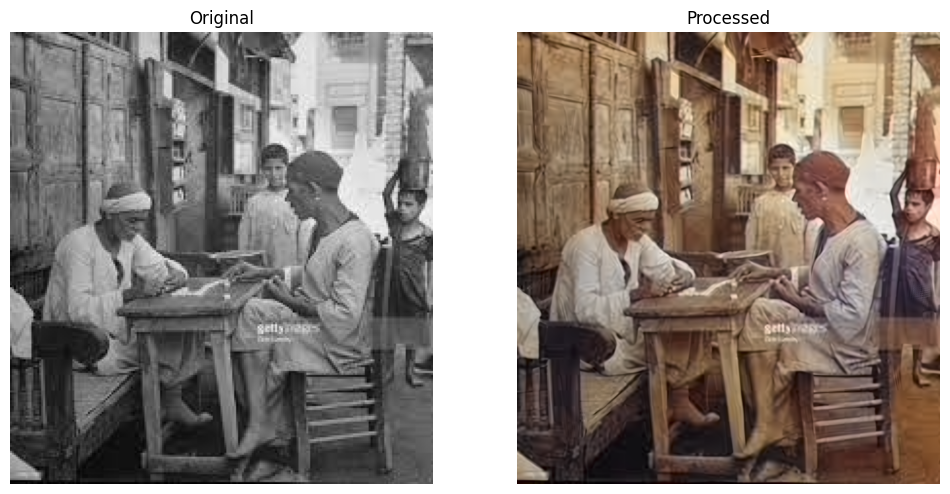

تم حفظ الصورة: C:/Users/lenovo/Desktop/MID Progect image proccess/im_processed.jpg


In [ ]:
import cv2                
import numpy as np        
import tkinter as tk      
from tkinter import filedialog
import matplotlib.pyplot as plt 

proto_file = "colorization_deploy_v2.prototxt"       
model_file = "colorization_release_v2.caffemodel"   
pts_file = "pts_in_hull.npy"                       


net = cv2.dnn.readNetFromCaffe(proto_file, model_file)


pts = np.load(pts_file)
class8 = net.getLayerId("class8_ab")       
conv8 = net.getLayerId("conv8_313_rh")    


pts = pts.transpose().reshape(2, 313, 1, 1)
net.getLayer(class8).blobs = [pts.astype(np.float32)]
net.getLayer(conv8).blobs = [np.full([1, 313], 2.606, np.float32)]


sr = cv2.dnn_superres.DnnSuperResImpl_create()  
sr.readModel("EDSR_x4.pb")                    
sr.setModel("edsr", 4)                        

def colorize_image(img):
    """
    هذه الدالة تأخذ صورة RGB بالأبيض والأسود أو الرمادي
    وتعيد نسخة ملونة باستخدام الشبكة العصبية.
    """
    h, w = img.shape[:2]                       
    img_rgb = (img.astype("float32") / 255.0)  


    lab = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2Lab)


    l = cv2.resize(lab[:, :, 0], (224, 224))
    l -= 50  


    net.setInput(cv2.dnn.blobFromImage(l))
    ab = net.forward()[0, :, :, :].transpose((1, 2, 0))  

    
    ab = cv2.resize(ab, (w, h))

    
    L = lab[:, :, 0]
    out_lab = np.concatenate((L[:, :, np.newaxis], ab), axis=2)

   
    out_rgb = cv2.cvtColor(out_lab, cv2.COLOR_Lab2RGB)
    return np.clip(out_rgb, 0, 1) 


def super_resolve(img):
    """
    هذه الدالة تكبر الصورة وتحسن التفاصيل باستخدام نموذج EDSR.
    """
    return sr.upsample(img)


def process_image(path, mode="both"):
    """
    path: مسار الصورة
    mode: نوع المعالجة "color" للتلوين فقط، 
          "sr" لتحسين الدقة فقط،
          "both" للتلوين + تحسين الدقة
    """
    img = cv2.imread(path)                    
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  
    result = img

    if mode == "color":
        result = (colorize_image(img) * 255).astype("uint8")
    elif mode == "sr":
        result = super_resolve(img)
    elif mode == "both":
        colored = (colorize_image(img) * 255).astype("uint8")
        result = super_resolve(colored)

    return img, result

def choose_file():
    root = tk.Tk()        
    root.withdraw()      
    return filedialog.askopenfilename()  

path = choose_file() 


original, output = process_image(path, mode="both") 

plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.imshow(original)
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(output)
plt.title("Processed")
plt.axis("off")
plt.show()

save_path = path.replace(".", "_processed.")  
cv2.imwrite(save_path, cv2.cvtColor(output, cv2.COLOR_RGB2BGR))
print("تم حفظ الصورة:", save_path)
